# Analise Exploratoria dos Dados na Bundesliga

Fonte: API do SofaScore. Disciplina: Mineracao Estatistica de Dados (SME0829).

Este notebook faz a analise exploratoria das estatisticas de jogadores da Bundesliga nas
temporadas 24/25 e 25/26, coletadas do SofaScore e organizadas em um banco DuckDB com esquema
estrela. O objetivo e entender a qualidade e o formato dos dados, descrever as principais
metricas de desempenho e levantar padroes que orientam a fase seguinte, a modelagem preditiva do
valor de mercado.

Roteiro da analise:

1. Carregamento e exploracao inicial dos dados
2. Estatisticas descritivas
3. Distribuicoes das variaveis principais
4. Analise por posicao
5. Comparacao entre temporadas
6. Correlacoes entre metricas
7. Destaques individuais
8. Eficiencia de conversao
9. Acoes por faixa etaria
10. Similaridade de atacantes por PCA

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Estilo visual padrao e resolucao das figuras.
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

# Banco analitico com esquema estrela gerado pela coleta do SofaScore.
# Abrimos em modo somente leitura por seguranca.
DB = "scrap-sofascore/db/sofascrap.duckdb"
con = duckdb.connect(DB, read_only=True)

# Uma consulta junta a tabela de fatos (estatisticas por jogador e temporada) com as
# dimensoes de jogador, temporada e time, trazendo tudo para um DataFrame.
df = con.sql("""
    SELECT
        p.player_id, p.name, p.position,
        s.season_id,
        s.name  AS season,
        t.name  AS team,
        f.minutes_played, f.matches_started, f.rating,
        f.goals, f.assists, f.goals_assists_sum, f.expected_assists,
        f.yellow_cards, f.red_cards,
        f.total_shots, f.shots_on_target,
        f.total_passes, f.accurate_passes, f.accurate_passes_pct, f.key_passes,
        f.successful_dribbles, f.tackles, f.interceptions,
        f.clearances, f.touches, f.aerial_duels_won,
        f.own_goals, f.offsides, f.penalty_goals
    FROM fact_ss_stats f
    JOIN dim_player_ss p USING (player_id)
    JOIN dim_season_ss s USING (season_id)
    JOIN dim_team_ss   t USING (team_id)
""").df()

# O identificador interno da temporada mais recente vem como codigo numerico; damos a ele um
# nome legivel para os graficos.
df["season"] = df["season"].replace({"77333": "Bundesliga 25/26"})

print(f"Shape: {df.shape}")
print(f"Temporadas: {sorted(df['season'].unique())}")
print(f"Posicoes:   {sorted(df['position'].unique())}")
df.head(3)

Shape: (860, 30)
Temporadas: ['Bundesliga 24/25', 'Bundesliga 25/26']
Posicoes:   ['D', 'F', 'G', 'M']


,player_id,name,position,season_id,season,team,minutes_played,matches_started,rating,goals,...,key_passes,successful_dribbles,tackles,interceptions,clearances,touches,aerial_duels_won,own_goals,offsides,penalty_goals
0,149728,Budu Zivzivadze,F,77333,Bundesliga 25/26,1. FC Heidenheim,758,10,6.460000,2,...,3,12,9,1,8,274,10,0,3,0
1,1067120,Eren Dinkçi,F,77333,Bundesliga 25/26,1. FC Heidenheim,1064,12,6.661111,1,...,7,9,21,8,9,501,2,0,0,0
2,909485,Marvin Pieringer,F,77333,Bundesliga 25/26,1. FC Heidenheim,1263,15,6.786364,4,...,13,13,15,8,26,536,46,0,9,1


## 1. Exploracao Inicial

O primeiro passo verifica a qualidade da coleta. Olhamos a completude de cada variavel, ou seja,
a porcentagem de registros preenchidos, e a distribuicao de jogadores por posicao e temporada.
Isso mostra se ha campos com muitos valores ausentes e se a base esta equilibrada entre as
posicoes.

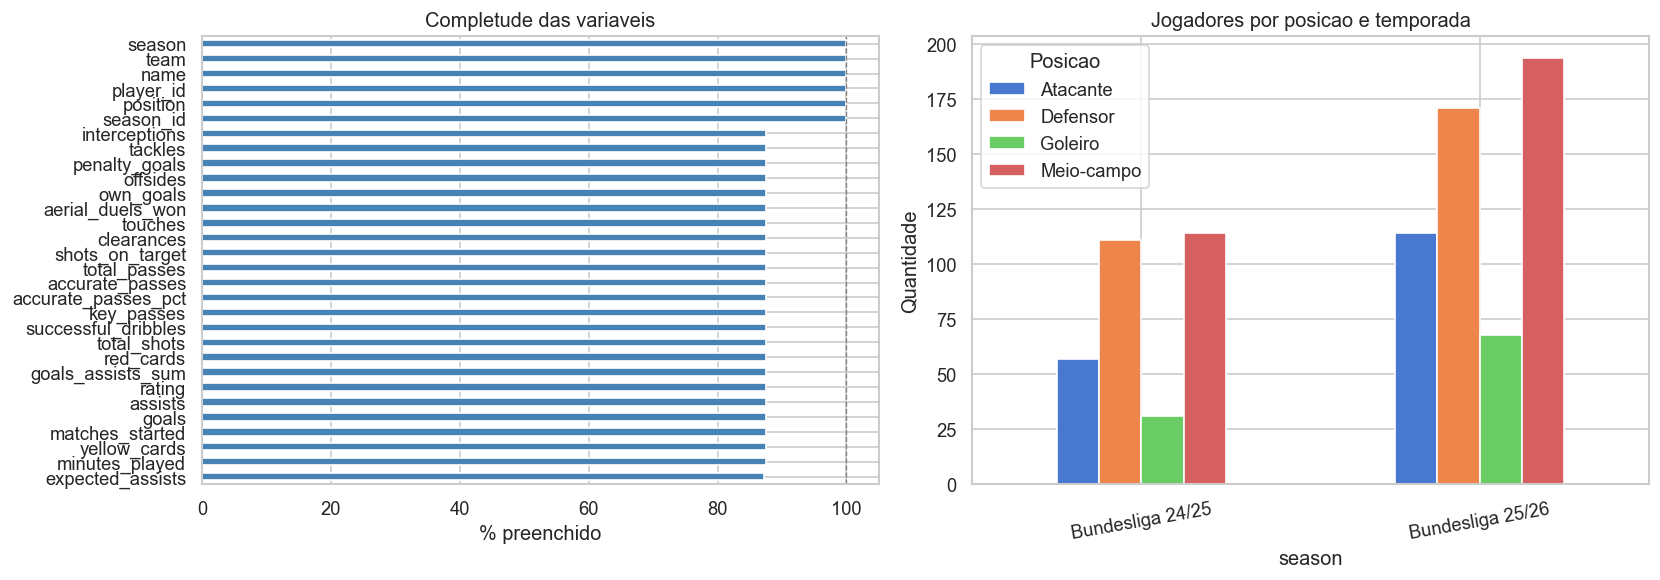

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Painel da esquerda: completude de cada coluna, do menos ao mais preenchido.
completude = df.notna().mean().sort_values() * 100
completude.plot.barh(ax=axes[0], color="steelblue")
axes[0].axvline(100, color="gray", lw=0.8, ls="--")   # referencia de 100 por cento
axes[0].set_xlabel("% preenchido")
axes[0].set_title("Completude das variaveis")

# Painel da direita: contagem de jogadores por posicao em cada temporada.
# Traduzimos o codigo de posicao para um rotulo legivel.
pos_map = {"F": "Atacante", "M": "Meio-campo", "D": "Defensor", "G": "Goleiro"}
df["pos_label"] = df["position"].map(pos_map)
tab = df.groupby(["season", "pos_label"]).size().unstack(fill_value=0)
tab.plot.bar(ax=axes[1], rot=10)
axes[1].set_title("Jogadores por posicao e temporada")
axes[1].set_ylabel("Quantidade")
axes[1].legend(title="Posicao")

plt.tight_layout()
plt.show()

## 2. Estatisticas Descritivas

A tabela abaixo resume as metricas centrais com media, desvio padrao, minimo, maximo e quartis.
Acrescentamos o coeficiente de variacao, que e o desvio padrao dividido pela media, para comparar
a dispersao relativa entre variaveis de escalas diferentes. Quanto maior esse coeficiente, mais
desigual e a metrica entre os jogadores.

In [3]:
# Conjunto de metricas centrais para o resumo estatistico.
metricas = ["minutes_played", "rating", "goals", "assists", "total_shots",
            "accurate_passes_pct", "successful_dribbles", "tackles", "yellow_cards"]

# describe() traz media, desvio, minimo, maximo e quartis; transpomos para ler por linha.
desc = df[metricas].describe().T
# Coeficiente de variacao: dispersao relativa a media, comparavel entre escalas diferentes.
desc["cv"] = desc["std"] / desc["mean"]
desc.style.format("{:.2f}").background_gradient(subset=["mean", "std", "cv"], cmap="Blues")

,count,mean,std,min,25%,50%,75%,max,cv
minutes_played,753.00,1272.92,837.59,1.00,506.00,1256.00,1947.00,3060.00,0.66
rating,753.00,6.76,0.76,0.00,6.64,6.80,6.97,9.70,0.11
goals,753.00,1.95,3.21,0.00,0.00,1.00,3.00,31.00,1.65
assists,753.00,1.37,2.08,0.00,0.00,1.00,2.00,18.00,1.53
total_shots,753.00,16.16,17.65,0.00,3.00,11.00,24.00,114.00,1.09
accurate_passes_pct,753.00,78.52,11.34,0.00,72.96,80.04,85.76,100.00,0.14
successful_dribbles,753.00,8.07,10.43,0.00,1.00,5.00,11.00,98.00,1.29
tackles,753.00,19.82,17.58,0.00,4.00,16.00,32.00,95.00,0.89
yellow_cards,753.00,2.33,2.21,0.00,1.00,2.00,4.00,11.00,0.95


## 3. Distribuicoes das Variaveis-Chave

Para seis metricas importantes, mostramos o histograma com uma curva de densidade sobreposta,
alem dos coeficientes de assimetria (skew) e de curtose. A assimetria indica se a distribuicao
pende para um lado, e a curtose indica o peso das caudas. Metricas ofensivas como gols e
assistencias tendem a ser bem assimetricas, com poucos jogadores concentrando a producao.

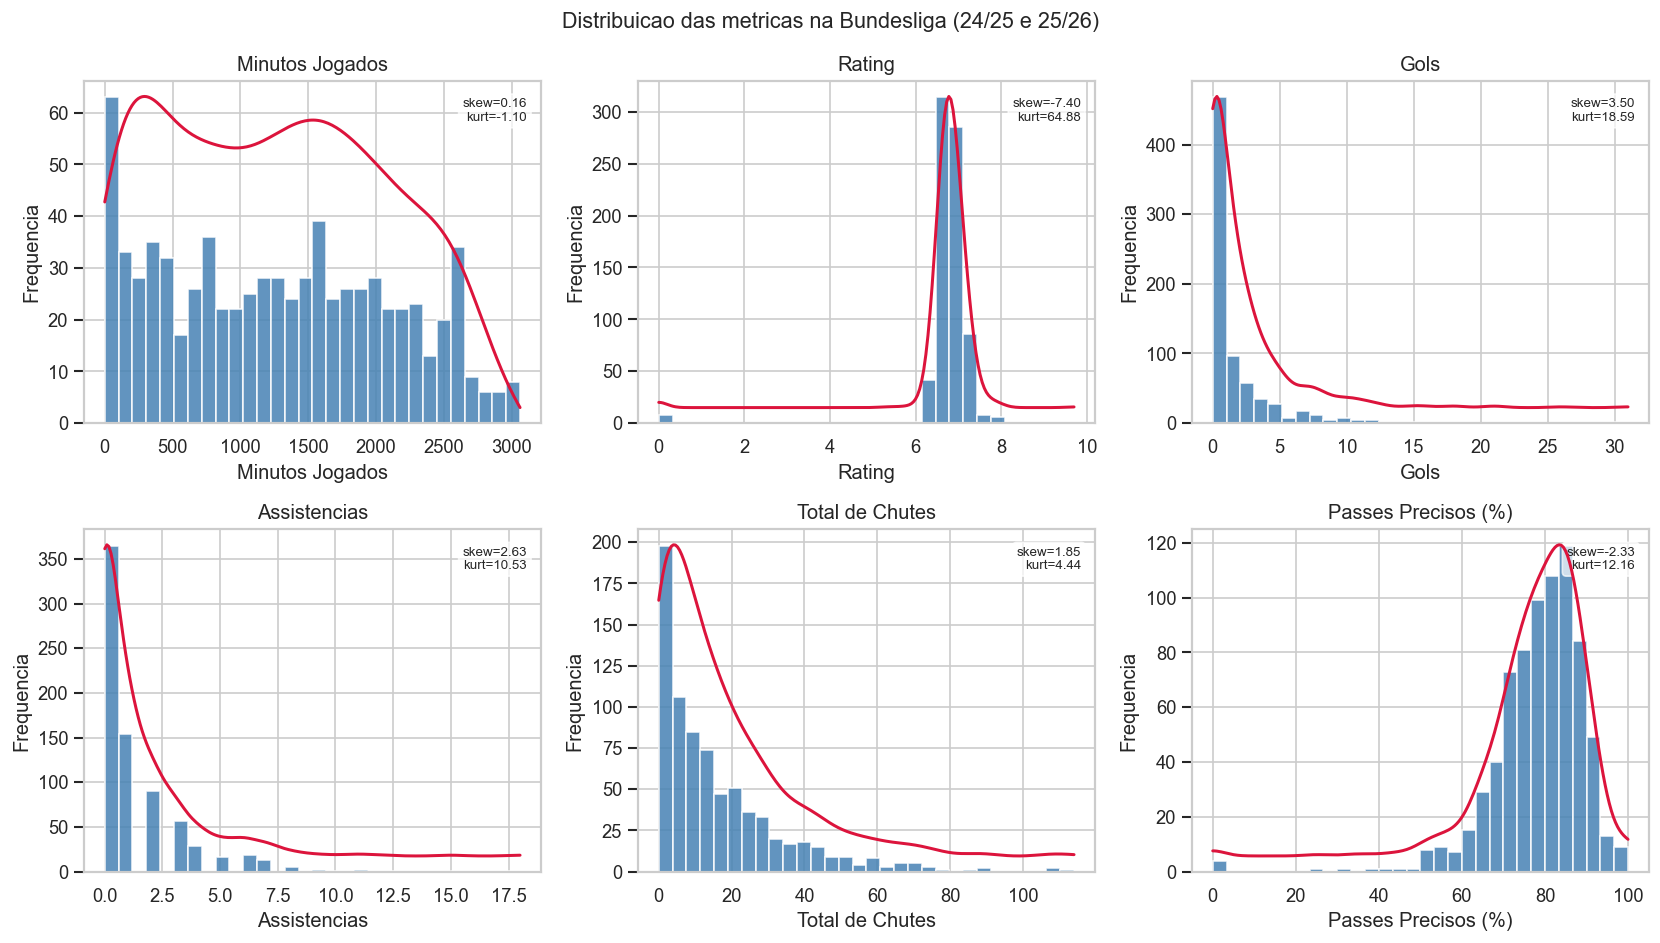

In [4]:
# Metricas a exibir e o rotulo amigavel de cada uma.
vars_plot = [
    ("minutes_played",     "Minutos Jogados"),
    ("rating",             "Rating"),
    ("goals",              "Gols"),
    ("assists",            "Assistencias"),
    ("total_shots",        "Total de Chutes"),
    ("accurate_passes_pct","Passes Precisos (%)"),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, (col, label) in zip(axes.flat, vars_plot):
    data = df[col].dropna()
    # Histograma da variavel.
    ax.hist(data, bins=30, edgecolor="white", color="steelblue", alpha=0.85)
    # Curva de densidade (KDE) desenhada em um eixo secundario, para sobrepor ao histograma.
    kde_x = np.linspace(data.min(), data.max(), 200)
    kde = stats.gaussian_kde(data)
    ax2 = ax.twinx()
    ax2.plot(kde_x, kde(kde_x), color="crimson", lw=1.8)
    ax2.set_yticks([])
    ax.set_title(label)
    ax.set_xlabel(label)
    ax.set_ylabel("Frequencia")
    # Anota assimetria e curtose no canto do grafico.
    sk, ku = data.skew(), data.kurt()
    ax.text(0.97, 0.95, f"skew={sk:.2f}\nkurt={ku:.2f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=8,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

fig.suptitle("Distribuicao das metricas na Bundesliga (24/25 e 25/26)", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Analise por Posicao

Aqui comparamos como as metricas variam entre atacantes, meio-campistas, defensores e goleiros.
Os boxplots mostram a mediana, a dispersao e os valores extremos de cada posicao, e a tabela
seguinte resume as medias considerando apenas jogadores com participacao relevante, de pelo menos
450 minutos, para evitar que reservas com poucos minutos distorçam os numeros.

C:\Users\Caio U. Evangelista\AppData\Local\Temp\ipykernel_7632\498746100.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="pos_label", y=col, order=order,
C:\Users\Caio U. Evangelista\AppData\Local\Temp\ipykernel_7632\498746100.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="pos_label", y=col, order=order,
C:\Users\Caio U. Evangelista\AppData\Local\Temp\ipykernel_7632\498746100.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="pos_label", y=col, order=order,
C:\Users\Caio U. Evangelista\AppData\

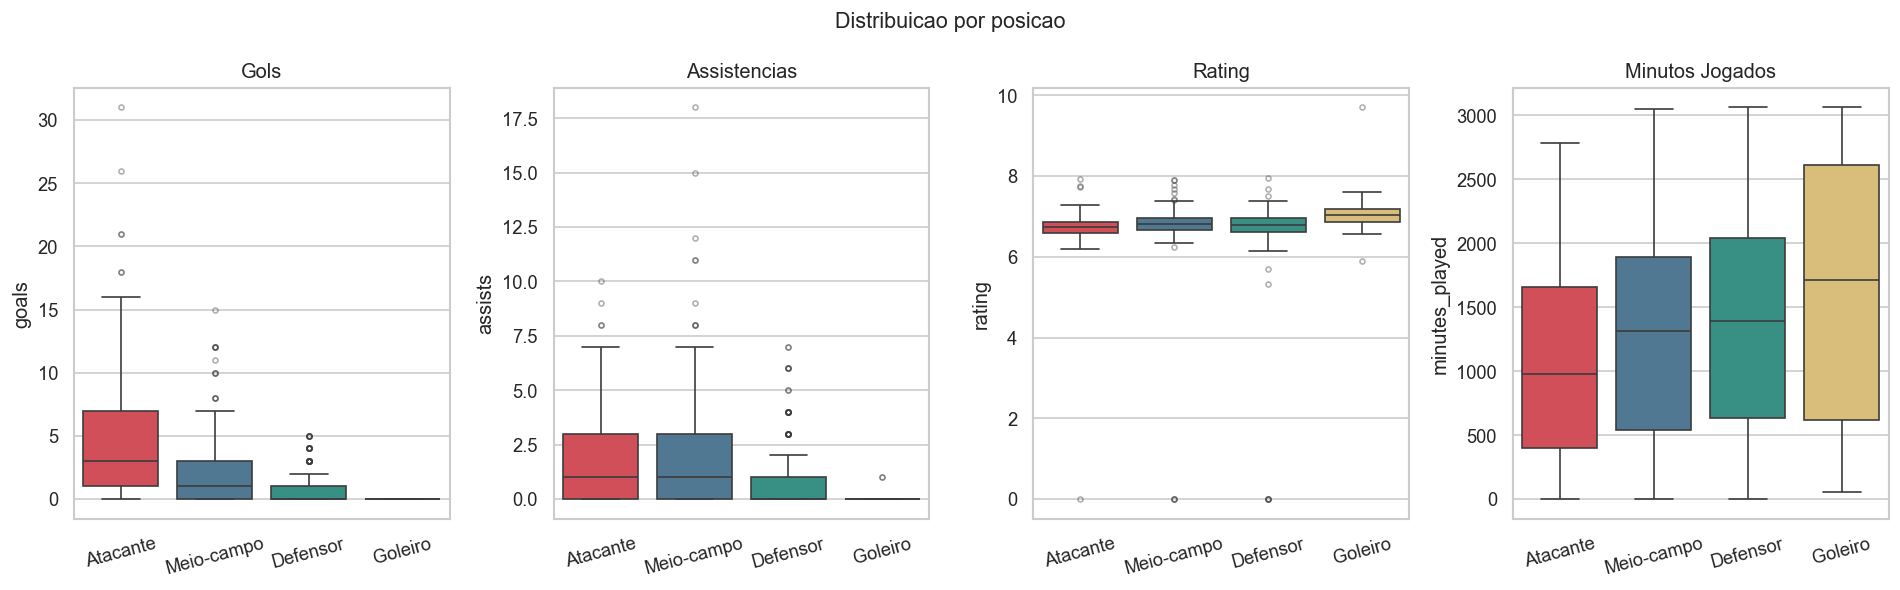

In [5]:
# Cores e ordem fixas das posicoes, para leitura consistente entre graficos.
palette = {"Atacante": "#e63946", "Meio-campo": "#457b9d",
           "Defensor": "#2a9d8f", "Goleiro": "#e9c46a"}
order = ["Atacante", "Meio-campo", "Defensor", "Goleiro"]

# Um boxplot por metrica, comparando as quatro posicoes.
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, (col, label) in zip(axes, [
    ("goals", "Gols"), ("assists", "Assistencias"),
    ("rating", "Rating"), ("minutes_played", "Minutos Jogados"),
]):
    sns.boxplot(data=df, x="pos_label", y=col, order=order,
                palette=palette, ax=ax,
                flierprops={"marker": ".", "alpha": 0.4})
    ax.set_title(label)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)

fig.suptitle("Distribuicao por posicao", fontsize=13)
plt.tight_layout()
plt.show()

In [6]:
# Medias por posicao considerando apenas quem jogou ao menos 450 minutos.
df_min = df[df["minutes_played"] >= 450].copy()
df_min["pos_label"] = df_min["position"].map(pos_map)

# Agrupa por posicao e calcula a media de cada metrica, na ordem definida antes.
media_pos = (
    df_min.groupby("pos_label")[metricas]
    .mean()
    .reindex(order)
)
media_pos.style.format("{:.2f}").background_gradient(cmap="YlOrRd")

,minutes_played,rating,goals,assists,total_shots,accurate_passes_pct,successful_dribbles,tackles,yellow_cards
pos_label,,,,,,,,,
Atacante,1359.71,6.83,5.86,2.28,37.66,72.71,13.88,14.15,2.15
Meio-campo,1579.64,6.89,2.38,2.38,22.71,80.28,13.42,30.04,3.09
Defensor,1648.80,6.84,1.08,1.04,11.45,84.37,6.12,30.43,3.43
Goleiro,1949.85,7.02,0.00,0.04,0.11,70.02,0.39,0.39,0.87


## 5. Comparacao entre Temporadas

Para saber se houve mudancas relevantes entre 24/25 e 25/26, comparamos a media de cada metrica
nas duas temporadas e aplicamos o teste t de Student, que verifica se a diferenca entre as medias
e estatisticamente significativa. Um valor de p abaixo de 0,05 indica diferenca significativa, e
marcamos esses casos com um asterisco.

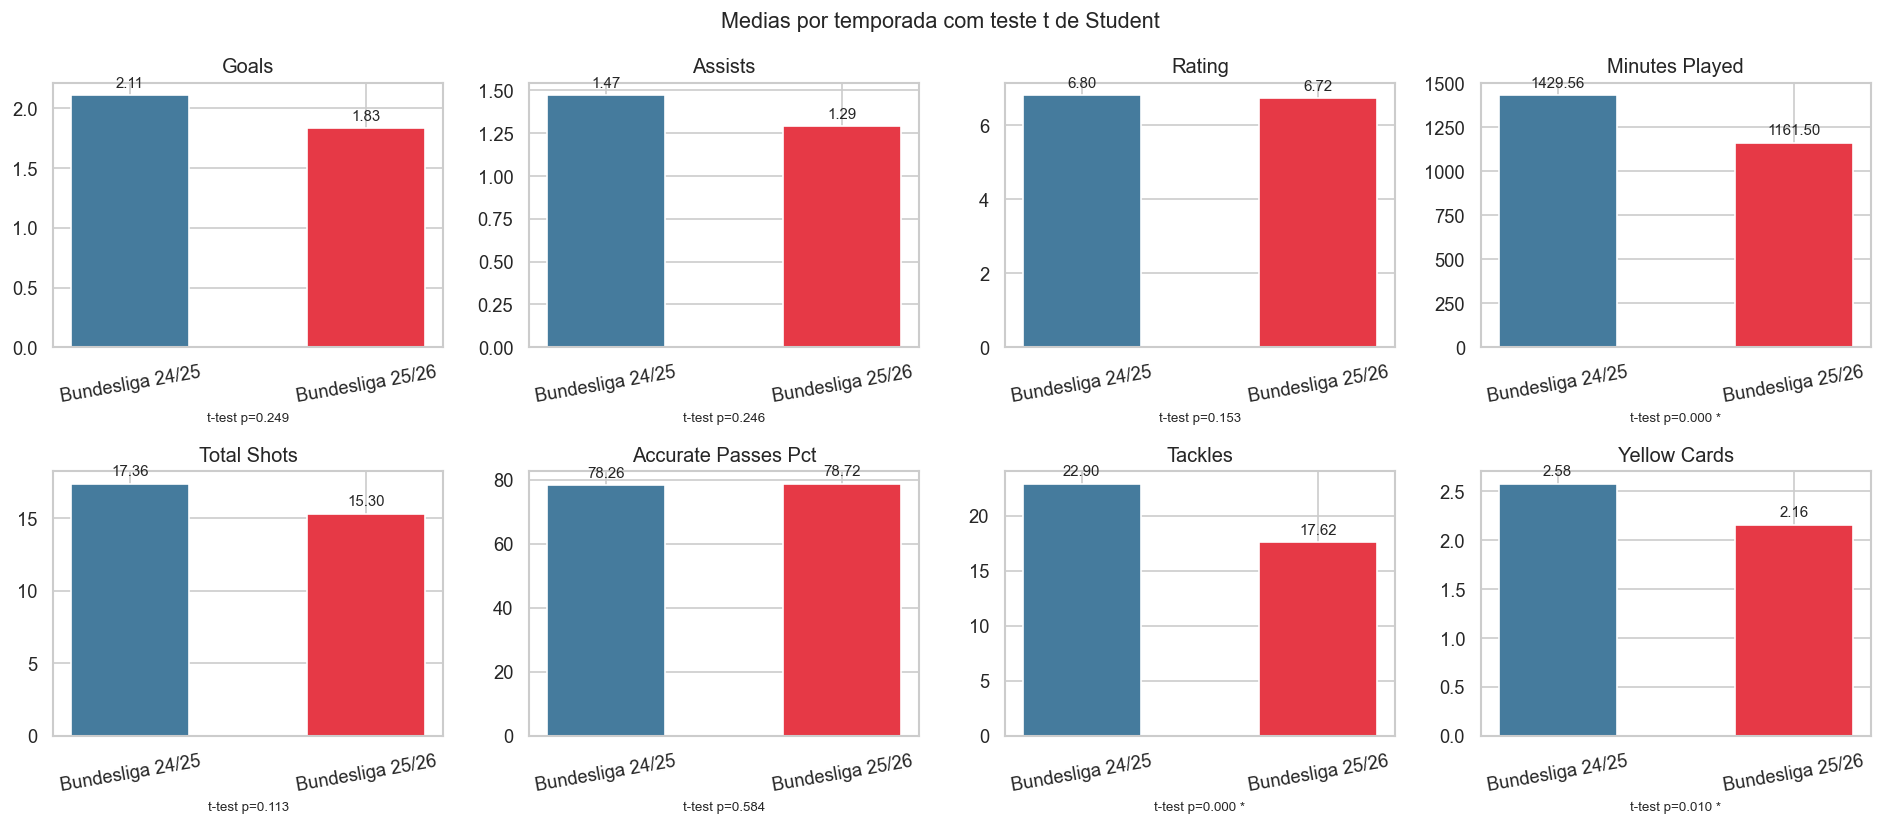

In [7]:
# Metricas comparadas entre as duas temporadas.
comp_metricas = ["goals", "assists", "rating", "minutes_played",
                 "total_shots", "accurate_passes_pct", "tackles", "yellow_cards"]

seasons = sorted(df["season"].unique())
medias = df.groupby("season")[comp_metricas].mean()
colors = ["#457b9d", "#e63946"]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, comp_metricas):
    # Barras com a media de cada temporada.
    vals = [medias.loc[s, col] for s in seasons]
    bars = ax.bar(seasons, vals, color=colors, edgecolor="white", width=0.5)
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
    ax.set_title(col.replace("_", " ").title())
    ax.tick_params(axis="x", rotation=10)
    # Teste t entre as duas temporadas; exige um minimo de observacoes de cada lado.
    s1, s2 = seasons[0], seasons[1]
    a = df.loc[df["season"] == s1, col].dropna()
    b = df.loc[df["season"] == s2, col].dropna()
    if len(a) > 5 and len(b) > 5:
        _, p = stats.ttest_ind(a, b)
        # Asterisco sinaliza diferenca estatisticamente significativa (p < 0,05).
        ax.set_xlabel(f"t-test p={p:.3f}" + (" *" if p < 0.05 else ""), fontsize=8)

fig.suptitle("Medias por temporada com teste t de Student", fontsize=13)
plt.tight_layout()
plt.show()

## 6. Correlacoes entre Metricas

O mapa de calor abaixo traz a correlacao de Spearman entre as metricas, calculada apenas para
jogadores com ao menos 450 minutos. Usamos Spearman, e nao Pearson, porque ele mede relacoes de
ordem e e mais robusto a distribuicoes assimetricas como as de gols e assistencias. Em seguida,
detalhamos a relacao entre chutes ao gol e gols para os atacantes.

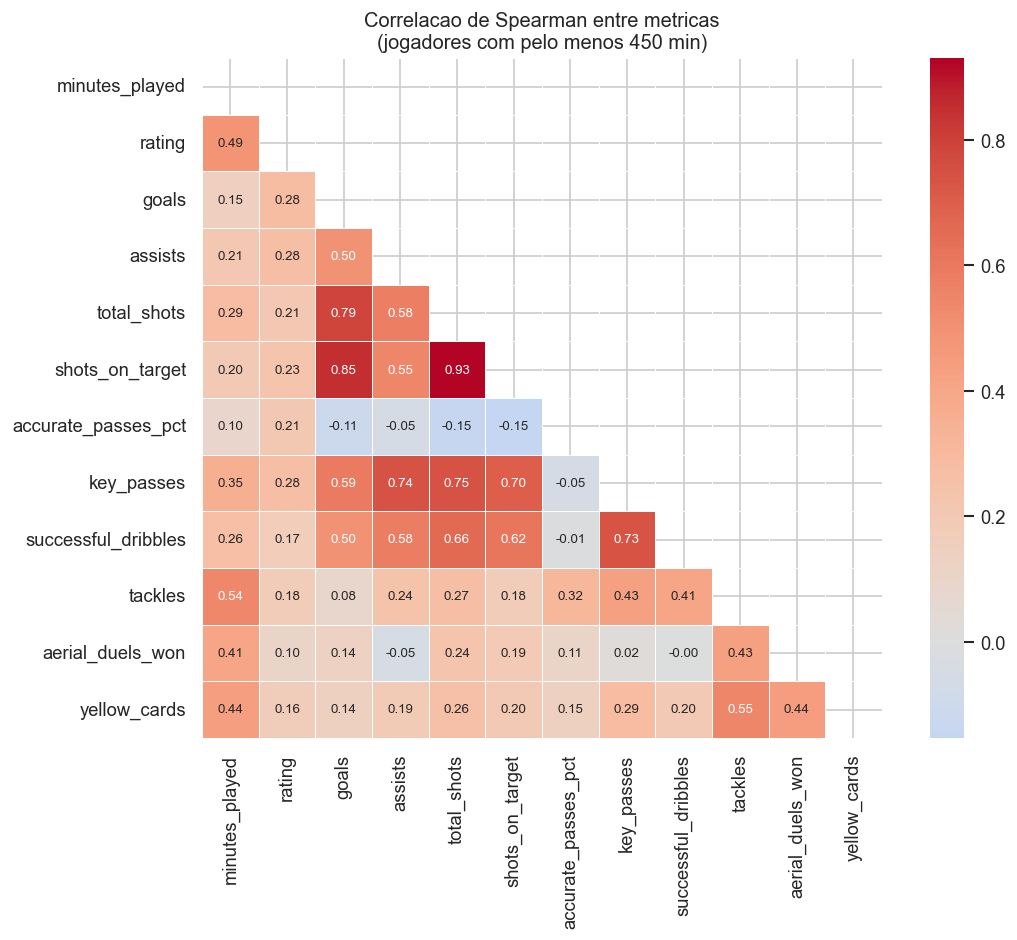

In [8]:
# Metricas incluidas na matriz de correlacao.
cols_corr = ["minutes_played", "rating", "goals", "assists", "total_shots",
             "shots_on_target", "accurate_passes_pct", "key_passes",
             "successful_dribbles", "tackles", "aerial_duels_won", "yellow_cards"]

# Correlacao de Spearman entre as metricas, so para quem tem 450 minutos ou mais.
corr = df_min[cols_corr].corr(method="spearman")
# Mascara para esconder o triangulo superior, evitando repetir a informacao.
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, square=True, ax=ax,
            annot_kws={"size": 8})
ax.set_title("Correlacao de Spearman entre metricas\n(jogadores com pelo menos 450 min)", fontsize=12)
plt.tight_layout()
plt.show()

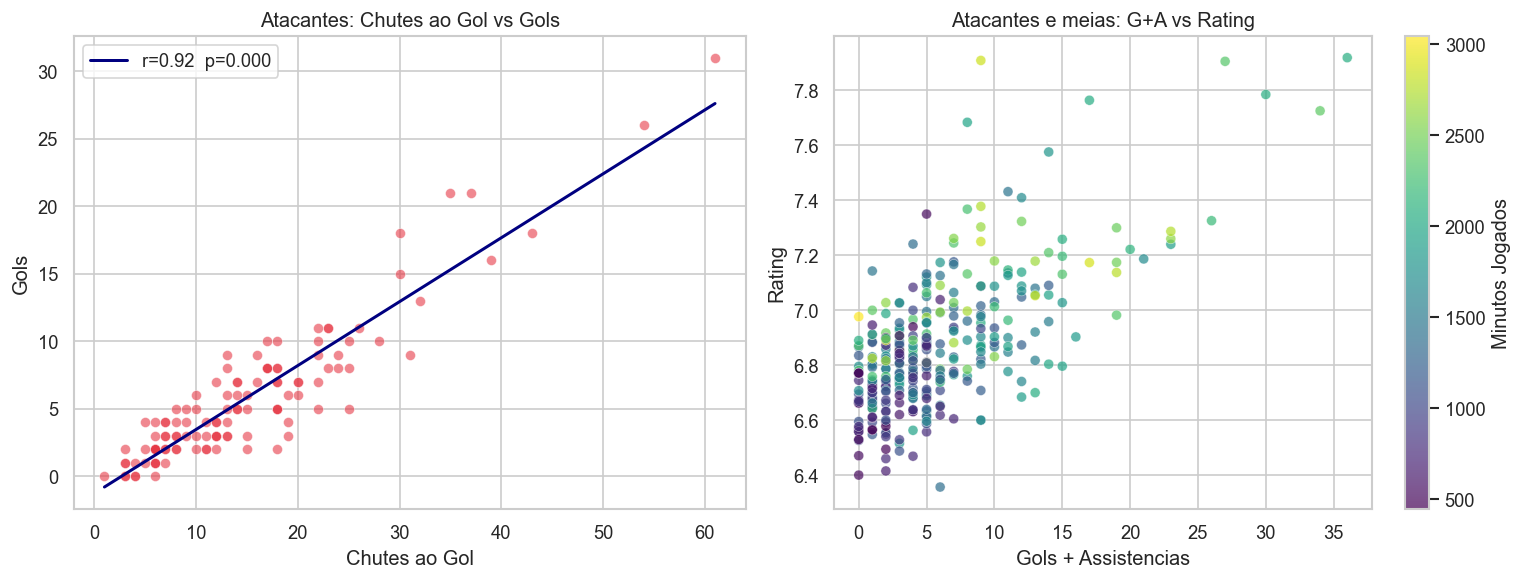

In [9]:
# Painel da esquerda: relacao entre chutes ao gol e gols, apenas para atacantes.
df_att = df_min[df_min["position"] == "F"].dropna(subset=["shots_on_target", "goals"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(df_att["shots_on_target"], df_att["goals"],
           alpha=0.6, color="#e63946", edgecolors="white", linewidths=0.4)
# Regressao linear simples para medir a forca da relacao (coeficiente r).
m, b, r, p, _ = stats.linregress(df_att["shots_on_target"], df_att["goals"])
x_line = np.linspace(df_att["shots_on_target"].min(), df_att["shots_on_target"].max(), 100)
ax.plot(x_line, m * x_line + b, color="navy", lw=1.8, label=f"r={r:.2f}  p={p:.3f}")
ax.set_xlabel("Chutes ao Gol")
ax.set_ylabel("Gols")
ax.set_title("Atacantes: Chutes ao Gol vs Gols")
ax.legend()

# Painel da direita: volume ofensivo (gols mais assistencias) contra rating, colorido pelos minutos.
df_ga = df_min[df_min["position"].isin(["F", "M"])].dropna(subset=["goals_assists_sum", "rating"])
ax = axes[1]
sc = ax.scatter(df_ga["goals_assists_sum"], df_ga["rating"],
                c=df_ga["minutes_played"], cmap="viridis",
                alpha=0.7, edgecolors="white", linewidths=0.3)
plt.colorbar(sc, ax=ax, label="Minutos Jogados")
ax.set_xlabel("Gols + Assistencias")
ax.set_ylabel("Rating")
ax.set_title("Atacantes e meias: G+A vs Rating")

plt.tight_layout()
plt.show()

## 7. Destaques Individuais

Esta secao lista os melhores jogadores em gols, assistencias, rating e volume ofensivo total,
considerando quem acumulou ao menos 900 minutos nas duas temporadas. Em seguida, somamos gols e
assistencias por time na temporada mais recente, para ver quais equipes tem o ataque mais
produtivo.

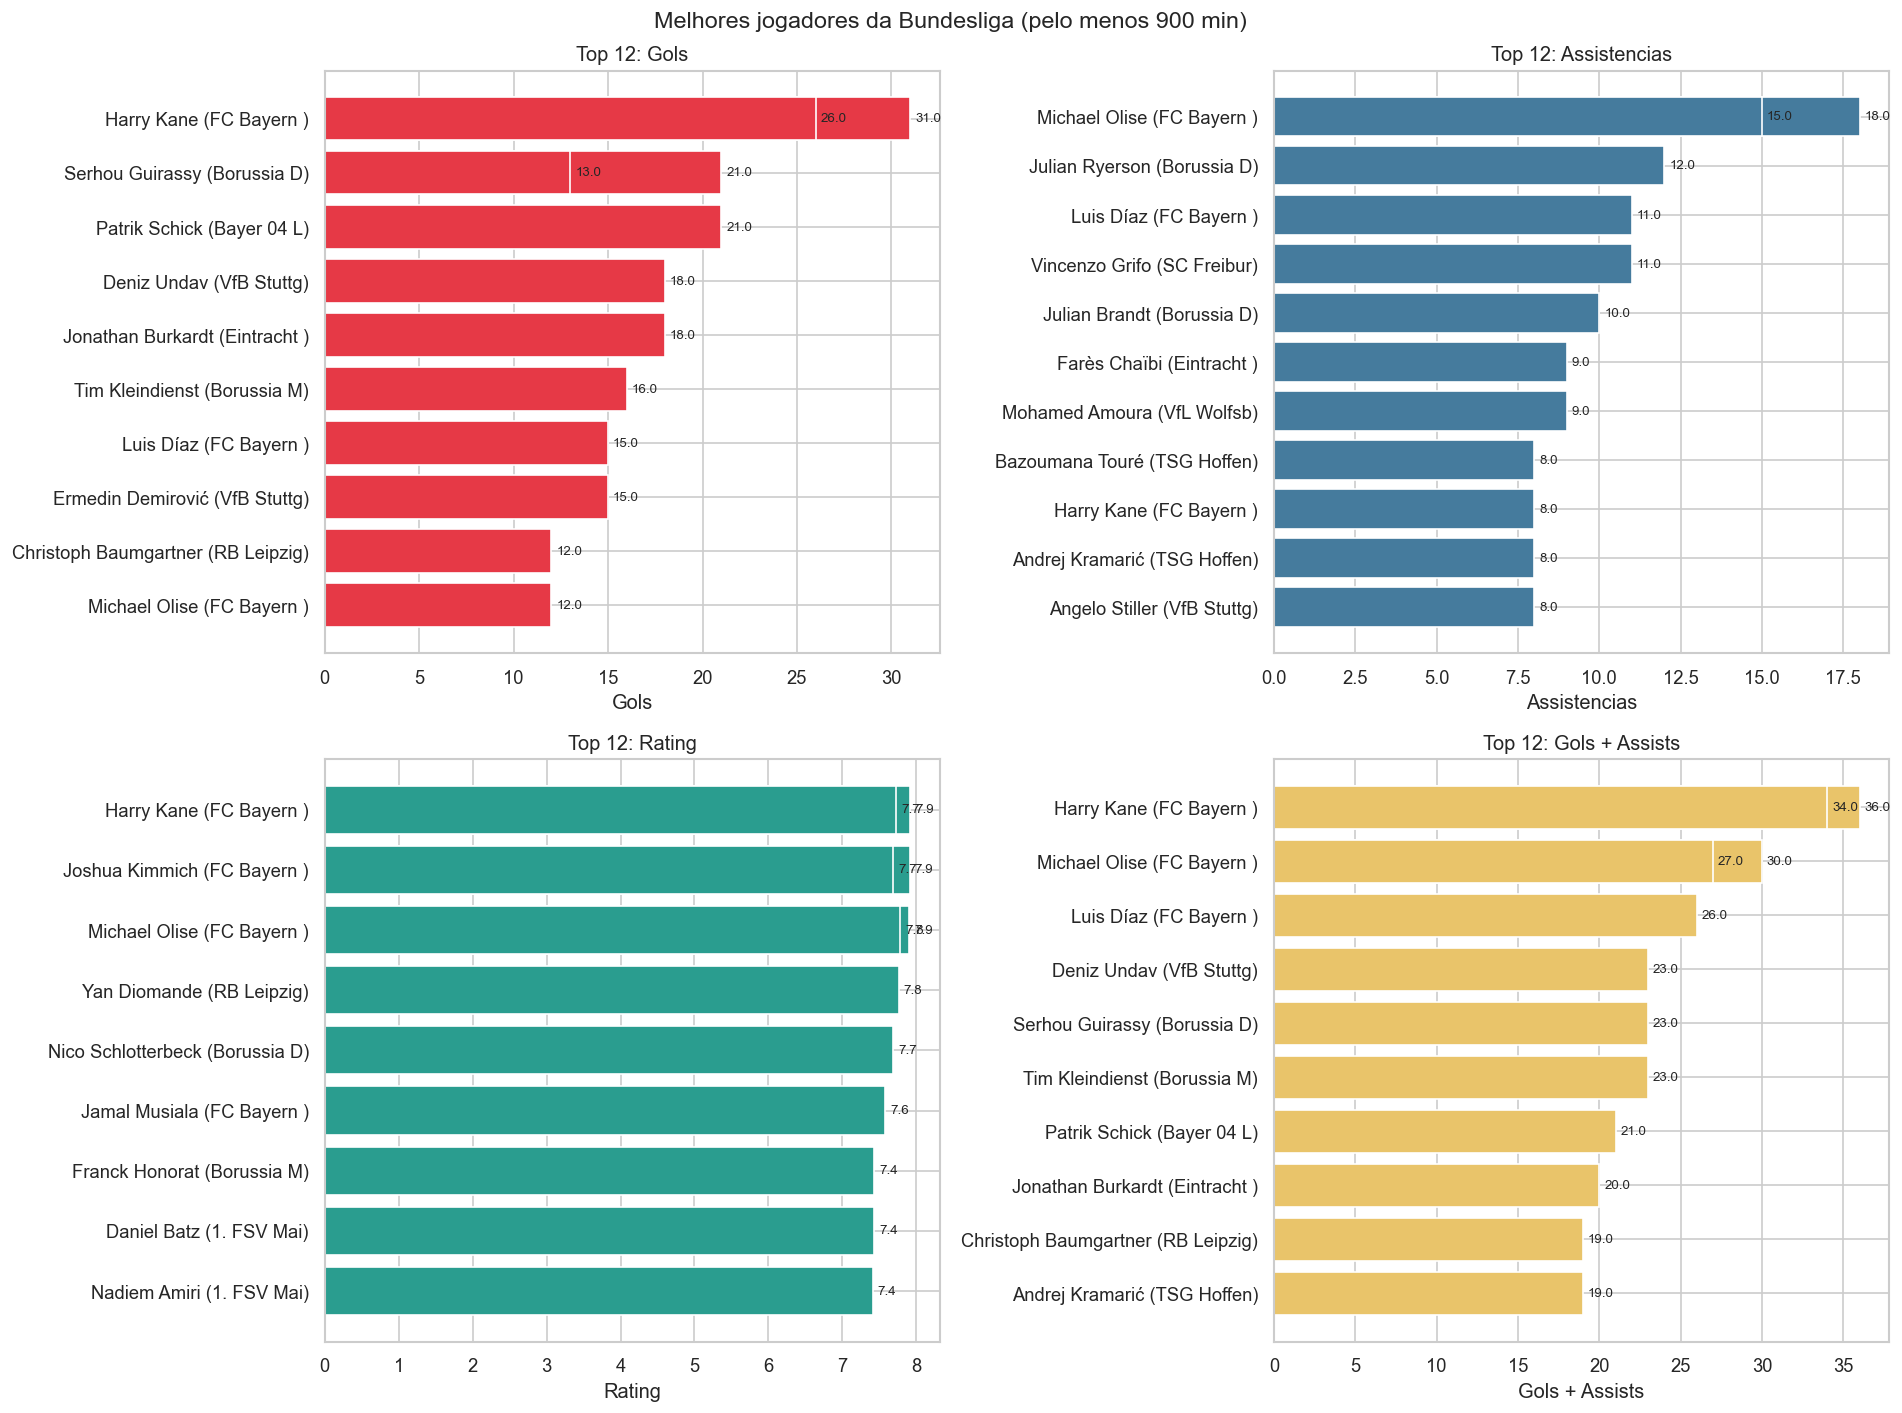

In [10]:
def top_chart(ax, df_src, col, label, color, n=12):
    """Desenha um grafico de barras horizontais com os n maiores valores de uma metrica."""
    top = df_src.nlargest(n, col)[["name", "team", col]].reset_index(drop=True)
    bars = ax.barh(top["name"] + " (" + top["team"].str[:10] + ")",
                   top[col], color=color, edgecolor="white")
    ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=8)
    ax.invert_yaxis()   # maior valor no topo
    ax.set_title(f"Top {n}: {label}")
    ax.set_xlabel(label)

# Considera apenas jogadores com volume relevante de minutos nas duas temporadas.
df_geral = df[df["minutes_played"] >= 900]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
top_chart(axes[0, 0], df_geral, "goals",            "Gols",           "#e63946")
top_chart(axes[0, 1], df_geral, "assists",           "Assistencias",   "#457b9d")
top_chart(axes[1, 0], df_geral, "rating",            "Rating",         "#2a9d8f")
top_chart(axes[1, 1], df_geral, "goals_assists_sum", "Gols + Assists",  "#e9c46a")

fig.suptitle("Melhores jogadores da Bundesliga (pelo menos 900 min)", fontsize=14)
plt.tight_layout()
plt.show()

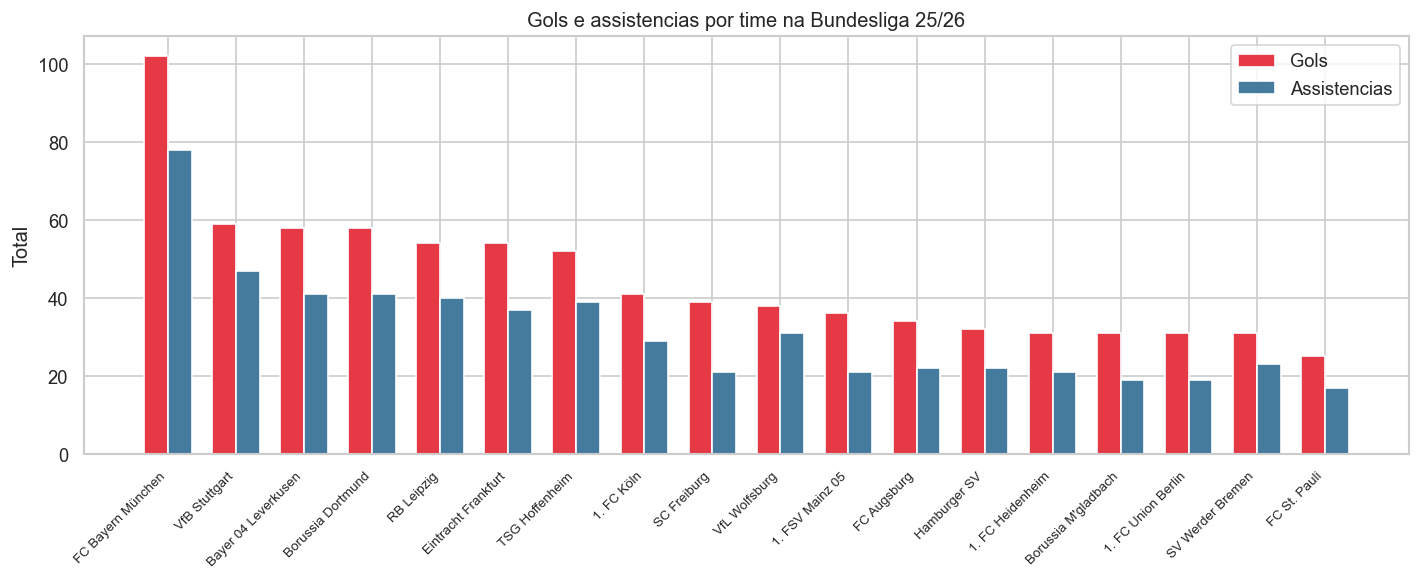

In [11]:
# Escolhe a temporada com mais registros, que e a mais completa na base.
temporada_recente = df["season"].value_counts().idxmax()
df_rec = df[df["season"] == temporada_recente]

# Soma de gols e assistencias por time, ordenada pelos gols.
team_stats = (
    df_rec.groupby("team")[["goals", "assists"]]
    .sum()
    .sort_values("goals", ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(team_stats))
w = 0.35
# Barras lado a lado: gols e assistencias por time.
ax.bar(x - w/2, team_stats["goals"],   width=w, label="Gols",        color="#e63946")
ax.bar(x + w/2, team_stats["assists"], width=w, label="Assistencias", color="#457b9d")
ax.set_xticks(x)
ax.set_xticklabels(team_stats.index, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Total")
ax.set_title(f"Gols e assistencias por time na {temporada_recente}")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Eficiencia de Conversao, Chutes ao Gol por Gol

A eficiencia de conversao mede quantos chutes ao gol um jogador precisa, em media, para marcar.
Quanto menor a razao, mais eficiente e o finalizador. Consideramos apenas quem fez ao menos 5 gols
somando as duas temporadas, para nao premiar acertos isolados. O grafico traz o ranking dos mais
eficientes e a dispersao geral, com Harry Kane destacado.

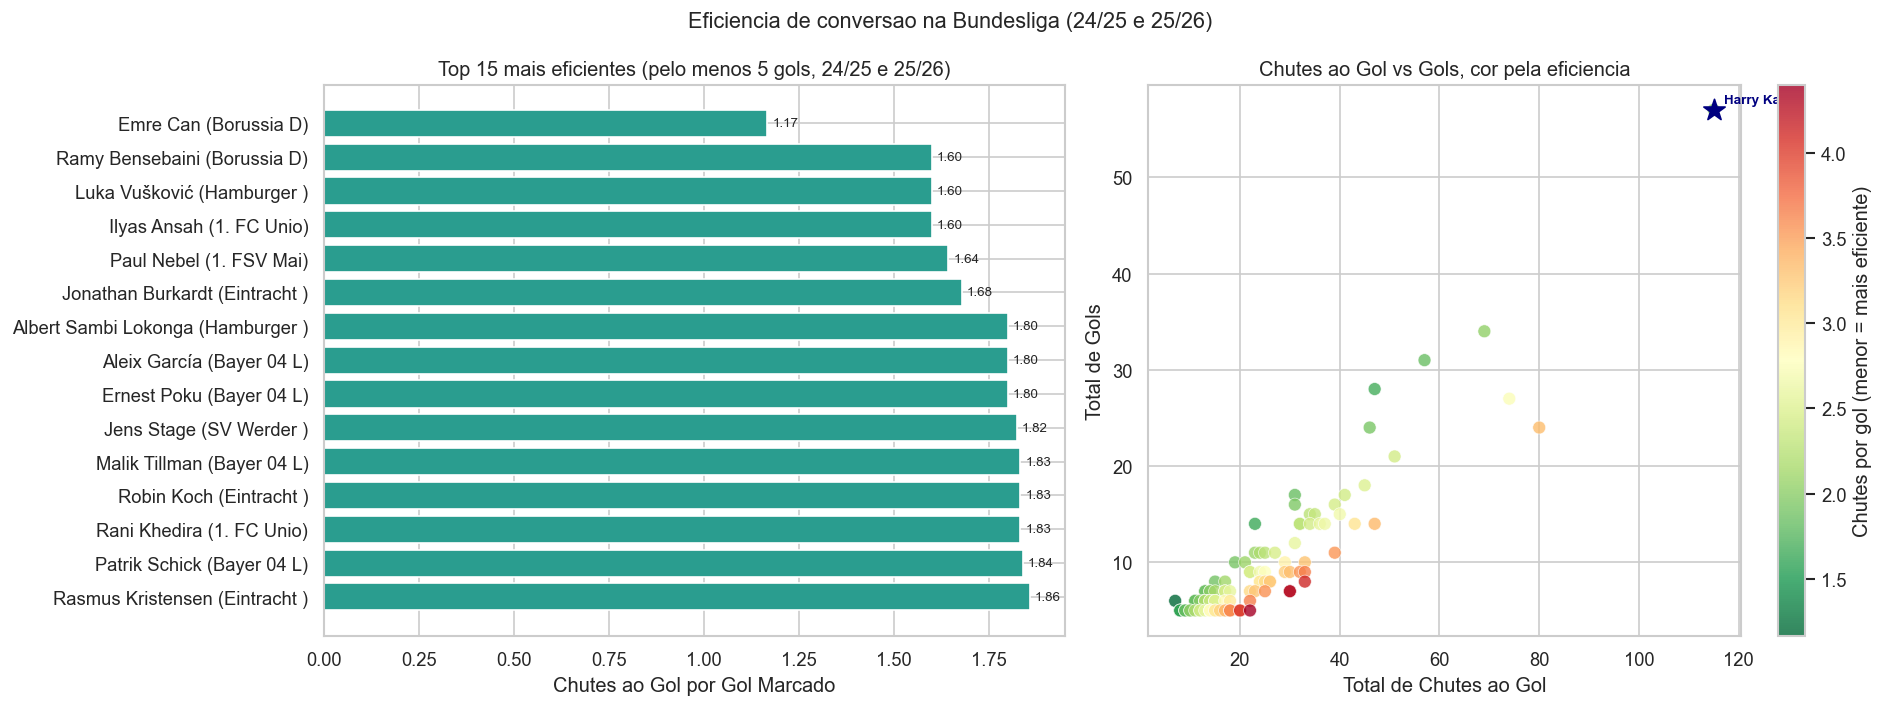

Top 5 mais eficientes (pelo menos 5 gols):
           name               team  goals  shots_on_target  chutes_por_gol
       Emre Can  Borussia Dortmund      6                7        1.166667
Ramy Bensebaini  Borussia Dortmund      5                8             1.6
  Luka Vušković       Hamburger SV      5                8             1.6
    Ilyas Ansah 1. FC Union Berlin      5                8             1.6
     Paul Nebel    1. FSV Mainz 05     14               23        1.642857


In [12]:
# Agrega as duas temporadas por jogador e mantem so quem finaliza (chutes ao gol > 0).
df_conv = (
    df[df["shots_on_target"] > 0]
    .groupby(["player_id", "name", "team", "position"])
    .agg(goals=("goals", "sum"), shots_on_target=("shots_on_target", "sum"))
    .reset_index()
)
# Exige um minimo de 5 gols para a razao ser confiavel.
df_conv = df_conv[df_conv["goals"] >= 5].copy()
# Razao de eficiencia: quantos chutes ao gol por gol marcado (menor e melhor).
df_conv["chutes_por_gol"] = df_conv["shots_on_target"] / df_conv["goals"]
df_conv = df_conv.sort_values("chutes_por_gol")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Painel da esquerda: ranking dos 15 mais eficientes.
top15 = df_conv.head(15)
bars = axes[0].barh(
    top15["name"] + " (" + top15["team"].str[:10] + ")",
    top15["chutes_por_gol"],
    color="#2a9d8f", edgecolor="white",
)
axes[0].bar_label(bars, fmt="%.2f", padding=3, fontsize=8)
axes[0].invert_yaxis()
axes[0].set_xlabel("Chutes ao Gol por Gol Marcado")
axes[0].set_title("Top 15 mais eficientes (pelo menos 5 gols, 24/25 e 25/26)")

# Painel da direita: dispersao de chutes ao gol contra gols, colorida pela eficiencia.
sc = axes[1].scatter(
    df_conv["shots_on_target"], df_conv["goals"],
    c=df_conv["chutes_por_gol"], cmap="RdYlGn_r",
    s=60, alpha=0.8, edgecolors="white", linewidths=0.4,
)
plt.colorbar(sc, ax=axes[1], label="Chutes por gol (menor = mais eficiente)")

# Destaca o Harry Kane, referencia de goleador de alto volume.
kane = df_conv[df_conv["name"] == "Harry Kane"]
if not kane.empty:
    axes[1].scatter(kane["shots_on_target"], kane["goals"],
                    s=180, color="navy", zorder=6, marker="*")
    axes[1].annotate(
        "Harry Kane",
        (kane["shots_on_target"].values[0], kane["goals"].values[0]),
        xytext=(6, 4), textcoords="offset points", fontsize=8,
        color="navy", fontweight="bold",
    )

axes[1].set_xlabel("Total de Chutes ao Gol")
axes[1].set_ylabel("Total de Gols")
axes[1].set_title("Chutes ao Gol vs Gols, cor pela eficiencia")

fig.suptitle("Eficiencia de conversao na Bundesliga (24/25 e 25/26)", fontsize=13)
plt.tight_layout()
plt.show()

print("Top 5 mais eficientes (pelo menos 5 gols):")
print(df_conv[["name", "team", "goals", "shots_on_target", "chutes_por_gol"]].head().to_string(index=False))

## 9. Acoes por Faixa Etaria

Nota: a idade e obtida do endpoint /player/{id} do SofaScore, pelo campo dateOfBirthTimestamp. A
celula abaixo primeiro tenta carregar as idades de um cache local em data/output/player_ages.csv e,
se ele nao existir, busca na API e salva o resultado. Caso a API esteja indisponivel e nao haja
cache, as analises desta secao ficam pendentes ate que o cache exista.

In [13]:
import time
from pathlib import Path
from curl_cffi import requests as cffi_requests

# Arquivo de cache das idades, para nao repetir as chamadas a API a cada execucao.
AGES_CACHE = Path("data/output/player_ages.csv")

def _fetch_ages(player_ids):
    """Busca a data de nascimento de cada jogador na API do SofaScore.

    Usa curl_cffi imitando um navegador Chrome para reduzir bloqueios e mantem uma pausa
    entre as chamadas. Retorna um dicionario de id do jogador para o instante de nascimento.
    """
    ages = {}
    session = cffi_requests.Session(impersonate="chrome146")
    for pid in player_ids:
        try:
            r = session.get(f"https://api.sofascore.com/api/v1/player/{pid}", timeout=5)
            if r.status_code == 200:
                ts = r.json().get("player", {}).get("dateOfBirthTimestamp")
                if ts:
                    ages[pid] = ts
        except Exception:
            pass
        time.sleep(0.25)   # pausa curta entre requisicoes
    return ages

all_ids = df["player_id"].unique().tolist()

# Caminho preferido: usar o cache se ele ja existe.
if AGES_CACHE.exists():
    df_ages = pd.read_csv(AGES_CACHE)
    df_ages["player_id"] = df_ages["player_id"].astype(int)
    print(f"Idades carregadas do cache: {len(df_ages)} jogadores")
    _age_available = True
else:
    # Sem cache: busca na API e salva para as proximas execucoes.
    print(f"Buscando idades de {len(all_ids)} jogadores na API...")
    ages = _fetch_ages(all_ids)
    if ages:
        df_ages = pd.DataFrame(list(ages.items()), columns=["player_id", "dob_ts"])
        AGES_CACHE.parent.mkdir(parents=True, exist_ok=True)
        df_ages.to_csv(AGES_CACHE, index=False)
        print(f"Idades salvas em cache: {len(df_ages)}/{len(all_ids)} jogadores")
        _age_available = True
    else:
        # API indisponivel e sem cache: sinaliza que as analises de idade ficam pendentes.
        df_ages = pd.DataFrame(columns=["player_id", "dob_ts"])
        _age_available = False
        print("API indisponivel. As analises de faixa etaria aguardam o cache em data/output/player_ages.csv")

Idades carregadas do cache: 1020 jogadores


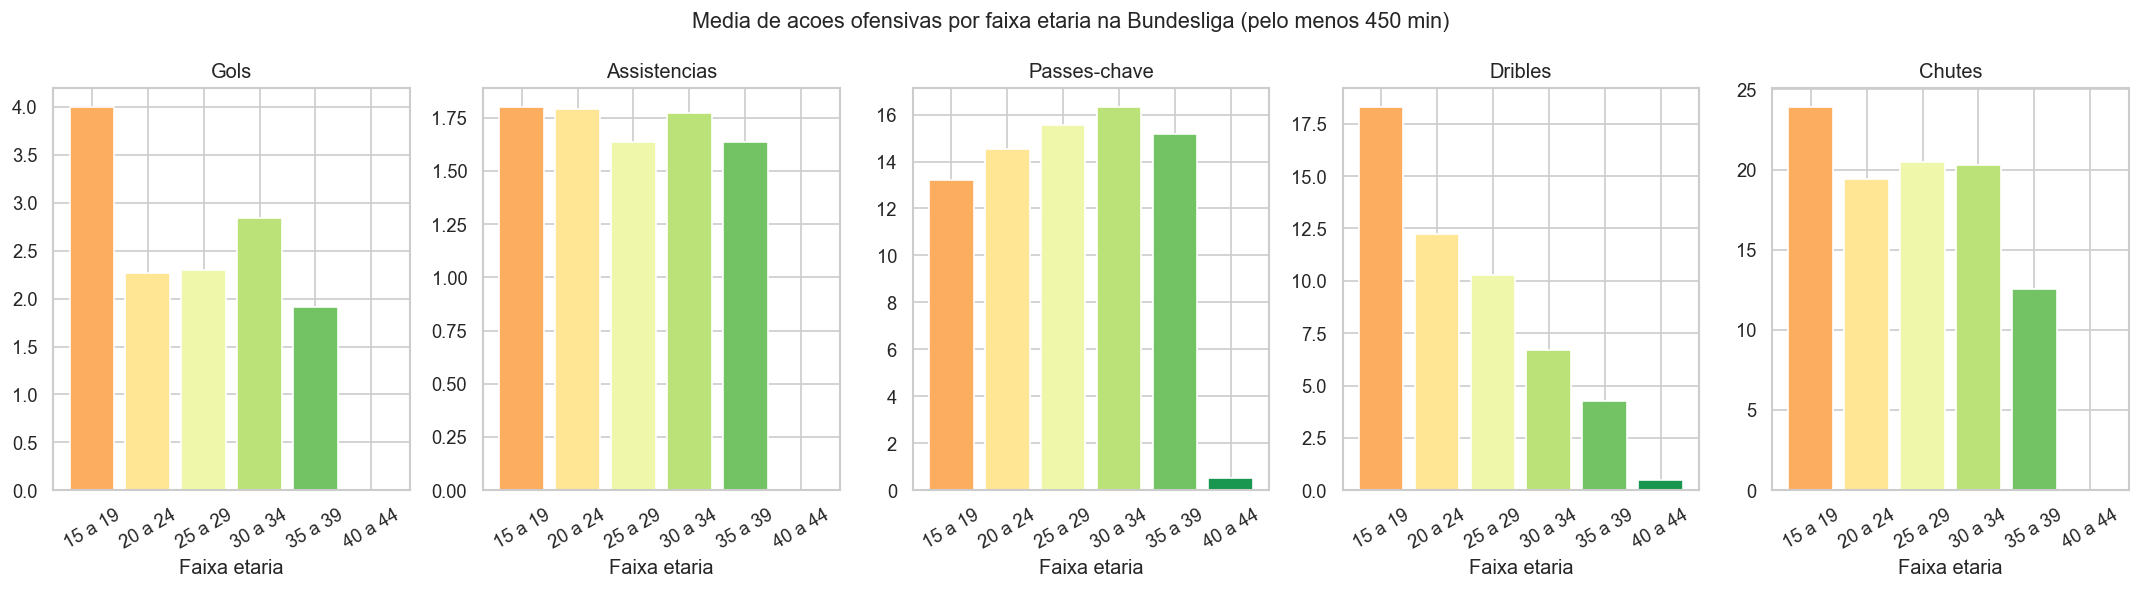


Jogador com maior score ofensivo por faixa etaria:
  faixa            name              team position  goals  assists  off_score
15 a 19    Yan Diomande        RB Leipzig        F     11        6       69.4
20 a 24   Michael Olise FC Bayern München        M     12       15       95.1
25 a 29       Luis Díaz FC Bayern München        M     15       11       73.9
30 a 34      Harry Kane FC Bayern München        F     31        5       62.7
35 a 39 Andrej Kramarić    TSG Hoffenheim        F     11        8       50.0
40 a 44    Manuel Neuer FC Bayern München        G      0        0        0.8


In [14]:
if not _age_available:
    print("Analise de acoes ofensivas por faixa etaria indisponivel. Veja a nota acima.")
else:
    from datetime import datetime

    # Converte o instante de nascimento em idade aproximada em anos.
    TODAY_TS = datetime.now().timestamp()
    df_ages["age"] = ((TODAY_TS - df_ages["dob_ts"]) / (365.25 * 24 * 3600)).astype(int)
    # Agrupa em faixas de 5 anos, por exemplo 20 a 24.
    df_ages["faixa"] = (
        (df_ages["age"] // 5 * 5).astype(str) + " a " +
        ((df_ages["age"] // 5 * 5) + 4).astype(str)
    )

    # Junta a idade ao dataset principal e mantem quem tem participacao relevante.
    df_age = df.merge(df_ages[["player_id", "age", "faixa"]], on="player_id", how="inner")
    df_age = df_age[df_age["minutes_played"] >= 450].copy()

    faixas_order = sorted(df_age["faixa"].unique(), key=lambda x: int(x.split(" a ")[0]))

    # Media das acoes ofensivas por faixa etaria.
    ofensivas = ["goals", "assists", "key_passes", "successful_dribbles", "total_shots"]
    labels_off = ["Gols", "Assistencias", "Passes-chave", "Dribles", "Chutes"]

    agg_off = df_age.groupby("faixa")[ofensivas].mean().loc[faixas_order]

    fig, axes = plt.subplots(1, len(ofensivas), figsize=(18, 5), sharey=False)
    cmap_off = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(faixas_order)))

    for ax, col, lbl in zip(axes, ofensivas, labels_off):
        ax.bar(agg_off.index, agg_off[col], color=cmap_off, edgecolor="white")
        ax.set_title(lbl)
        ax.set_xlabel("Faixa etaria")
        ax.tick_params(axis="x", rotation=30)

    fig.suptitle("Media de acoes ofensivas por faixa etaria na Bundesliga (pelo menos 450 min)", fontsize=13)
    plt.tight_layout()
    plt.show()

    # Score ofensivo simples: combina gols, assistencias, passes-chave e dribles com pesos.
    df_age["off_score"] = (
        df_age["goals"].fillna(0) +
        df_age["assists"].fillna(0) +
        df_age["key_passes"].fillna(0) * 0.5 +
        df_age["successful_dribbles"].fillna(0) * 0.3
    )
    # Jogador de maior score ofensivo em cada faixa etaria.
    top_off = (
        df_age.sort_values("off_score", ascending=False)
        .groupby("faixa", sort=False)
        .first()
        .loc[faixas_order]
        .reset_index()
        [["faixa", "name", "team", "position", "goals", "assists", "off_score"]]
    )
    print("\nJogador com maior score ofensivo por faixa etaria:")
    print(top_off.to_string(index=False))

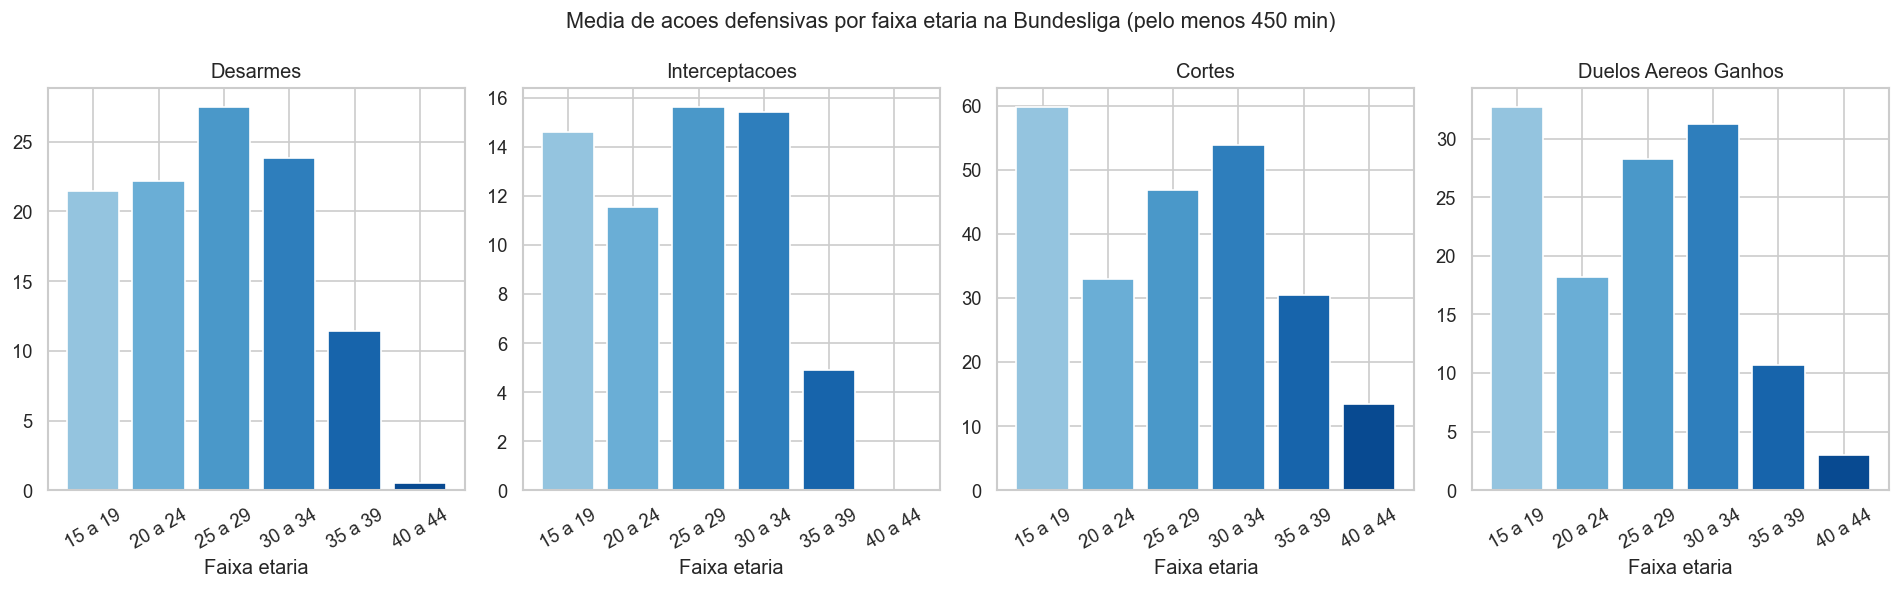


Jogador com maior score defensivo por faixa etaria:
  faixa                name                team position  tackles  interceptions  def_score
15 a 19       Luka Vušković        Hamburger SV        D       21             31      303.4
20 a 24    Leopold Querfeld  1. FC Union Berlin        D       48             32      301.7
25 a 29         Nico Elvedi Borussia M'gladbach        D       38             32      290.2
30 a 34      Patrick Mainka    1. FC Heidenheim        D       58             68      344.5
35 a 39 Christopher Trimmel  1. FC Union Berlin        M       38             18      136.8
40 a 44        Manuel Neuer   FC Bayern München        G        1              0       14.7


In [15]:
if not _age_available:
    print("Analise de acoes defensivas por faixa etaria indisponivel. Veja a nota acima.")
else:
    # Media das acoes defensivas por faixa etaria.
    defensivas = ["tackles", "interceptions", "clearances", "aerial_duels_won"]
    labels_def = ["Desarmes", "Interceptacoes", "Cortes", "Duelos Aereos Ganhos"]

    agg_def = df_age.groupby("faixa")[defensivas].mean().loc[faixas_order]

    fig, axes = plt.subplots(1, len(defensivas), figsize=(16, 5), sharey=False)
    cmap_def = plt.cm.Blues(np.linspace(0.4, 0.9, len(faixas_order)))

    for ax, col, lbl in zip(axes, defensivas, labels_def):
        ax.bar(agg_def.index, agg_def[col], color=cmap_def, edgecolor="white")
        ax.set_title(lbl)
        ax.set_xlabel("Faixa etaria")
        ax.tick_params(axis="x", rotation=30)

    fig.suptitle("Media de acoes defensivas por faixa etaria na Bundesliga (pelo menos 450 min)", fontsize=13)
    plt.tight_layout()
    plt.show()

    # Score defensivo simples: combina desarmes, interceptacoes, cortes e duelos aereos com pesos.
    df_age["def_score"] = (
        df_age["tackles"].fillna(0) +
        df_age["interceptions"].fillna(0) +
        df_age["clearances"].fillna(0) * 0.8 +
        df_age["aerial_duels_won"].fillna(0) * 0.5
    )
    # Jogador de maior score defensivo em cada faixa etaria.
    top_def = (
        df_age.sort_values("def_score", ascending=False)
        .groupby("faixa", sort=False)
        .first()
        .loc[faixas_order]
        .reset_index()
        [["faixa", "name", "team", "position", "tackles", "interceptions", "def_score"]]
    )
    print("\nJogador com maior score defensivo por faixa etaria:")
    print(top_def.to_string(index=False))

## 10. Similaridade de Atacantes por PCA

A Analise de Componentes Principais (PCA) reduz varias metricas de desempenho a duas dimensoes que
preservam o maximo de variacao dos dados. Projetando os atacantes nesse espaco, jogadores com perfil
parecido ficam proximos. Usamos isso para achar os atacantes mais parecidos com Harry Kane, medindo a
distancia ate ele no grafico. E um primeiro passo em direcao a um sistema de recomendacao de perfis.

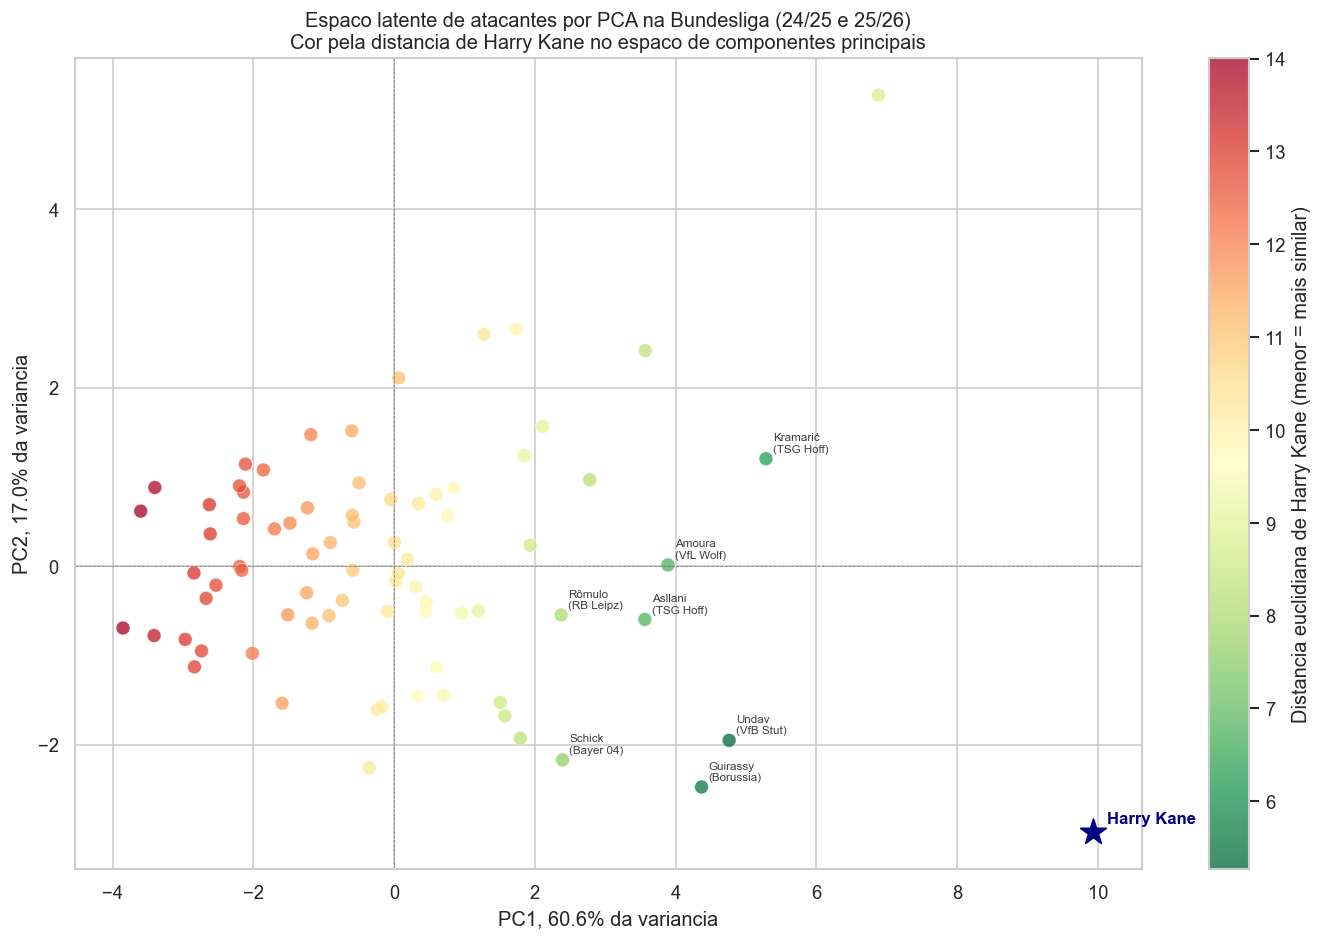

Variancia explicada: PC1=60.6%  PC2=17.0%

Top 10 atacantes mais similares a Harry Kane (pelo menos 450 min):
                 name                team  goals  assists  shots_on_target  dist_kane
          Deniz Undav       VfB Stuttgart   13.5      4.0             37.0   5.276085
      Serhou Guirassy   Borussia Dortmund   17.0      1.5             34.5   5.590331
      Andrej Kramarić      TSG Hoffenheim   10.5      6.5             25.5   6.252624
       Mohamed Amoura       VfL Wolfsburg    9.0      6.0             22.5   6.743379
       Fisnik Asllani      TSG Hoffenheim    9.0      6.0             24.0   6.801497
        Patrik Schick Bayer 04 Leverkusen   15.5      1.5             28.5   7.585878
               Rômulo          RB Leipzig    8.0      4.0             24.0   7.943321
Alexis Claude-Maurice         FC Augsburg    7.0      3.0             23.5   8.170432
    Jonathan Burkardt Eintracht Frankfurt   14.0      1.0             23.5   8.208452
        Julian Brandt   Boruss

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Metricas de desempenho que descrevem o perfil ofensivo de um atacante.
features_pca = [
    "goals", "assists", "total_shots", "shots_on_target",
    "key_passes", "successful_dribbles", "accurate_passes_pct",
    "goals_assists_sum", "expected_assists", "minutes_played",
]

# Media das duas temporadas por atacante, mantendo apenas quem tem todas as metricas.
df_fwd = (
    df[df["position"] == "F"]
    .groupby(["player_id", "name", "team"])
    .agg({col: "mean" for col in features_pca})
    .reset_index()
    .dropna(subset=features_pca)
)
df_fwd = df_fwd[df_fwd["minutes_played"] >= 450].reset_index(drop=True)

# Padroniza as metricas (media 0, desvio 1) antes do PCA, pois elas tem escalas diferentes.
X = StandardScaler().fit_transform(df_fwd[features_pca])
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)
df_fwd["PC1"] = coords[:, 0]
df_fwd["PC2"] = coords[:, 1]

# Distancia euclidiana de cada atacante ate o Harry Kane no espaco das componentes.
kane_mask = df_fwd["name"] == "Harry Kane"
kane_pc = df_fwd.loc[kane_mask, ["PC1", "PC2"]].values[0]
df_fwd["dist_kane"] = np.sqrt((df_fwd["PC1"] - kane_pc[0])**2 + (df_fwd["PC2"] - kane_pc[1])**2)

fig, ax = plt.subplots(figsize=(12, 8))

# Cada ponto e um atacante; a cor indica a proximidade ao Kane (verde mais parecido).
sc = ax.scatter(
    df_fwd.loc[~kane_mask, "PC1"],
    df_fwd.loc[~kane_mask, "PC2"],
    c=df_fwd.loc[~kane_mask, "dist_kane"],
    cmap="RdYlGn_r",
    s=70, alpha=0.75, edgecolors="white", linewidths=0.4,
)
plt.colorbar(sc, ax=ax, label="Distancia euclidiana de Harry Kane (menor = mais similar)")

# Marca o proprio Kane com uma estrela.
ax.scatter(*kane_pc, s=260, color="navy", zorder=7, marker="*")
ax.annotate("Harry Kane", kane_pc, xytext=(8, 5),
            textcoords="offset points", fontsize=10, color="navy", fontweight="bold")

# Anota os 7 atacantes mais parecidos com o Kane.
for _, row in df_fwd[~kane_mask].nsmallest(7, "dist_kane").iterrows():
    ax.annotate(
        row["name"].split()[-1] + f"\n({row['team'][:8]})",
        (row["PC1"], row["PC2"]),
        xytext=(4, 4), textcoords="offset points", fontsize=7, alpha=0.9,
    )

# Os eixos mostram quanto da variancia total cada componente explica.
ax.set_xlabel(f"PC1, {pca.explained_variance_ratio_[0]*100:.1f}% da variancia")
ax.set_ylabel(f"PC2, {pca.explained_variance_ratio_[1]*100:.1f}% da variancia")
ax.set_title(
    "Espaco latente de atacantes por PCA na Bundesliga (24/25 e 25/26)\n"
    "Cor pela distancia de Harry Kane no espaco de componentes principais",
    fontsize=12,
)
ax.axhline(0, color="gray", lw=0.5, ls="--")
ax.axvline(0, color="gray", lw=0.5, ls="--")
plt.tight_layout()
plt.show()

print(f"Variancia explicada: PC1={pca.explained_variance_ratio_[0]*100:.1f}%  PC2={pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"\nTop 10 atacantes mais similares a Harry Kane (pelo menos 450 min):")
cols_show = ["name", "team", "goals", "assists", "shots_on_target", "dist_kane"]
print(df_fwd[~kane_mask].nsmallest(10, "dist_kane")[cols_show].to_string(index=False))